<a href="https://colab.research.google.com/github/Arif0000/GFG-21-Days-Live-class-task/blob/main/Task_14_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Loaded Successfully
Shape: (151, 25)

Columns in Dataset:

Index(['life_insurer', 'year', 'claims_pending_start_no',
       'claims_pending_start_amt', 'claims_intimated_no',
       'claims_intimated_amt', 'total_claims_no', 'total_claims_amt',
       'claims_paid_no', 'claims_paid_amt', 'claims_repudiated_no',
       'claims_repudiated_amt', 'claims_rejected_no', 'claims_rejected_amt',
       'claims_unclaimed_no', 'claims_unclaimed_amt', 'claims_pending_end_no',
       'claims_pending_end_amt', 'claims_paid_ratio_no',
       'claims_paid_ratio_amt', 'claims_repudiated_rejected_ratio_no',
       'claims_repudiated_rejected_ratio_amt', 'claims_pending_ratio_no',
       'claims_pending_ratio_amt', 'category'],
      dtype='object')

First 5 Rows
  life_insurer     year  claims_pending_start_no  claims_pending_start_amt  \
0         ABSL  2021-22                     11.0              3.637908e+00   
1        Aegon  2021-22                      0.0              0.000000e+00   
2  

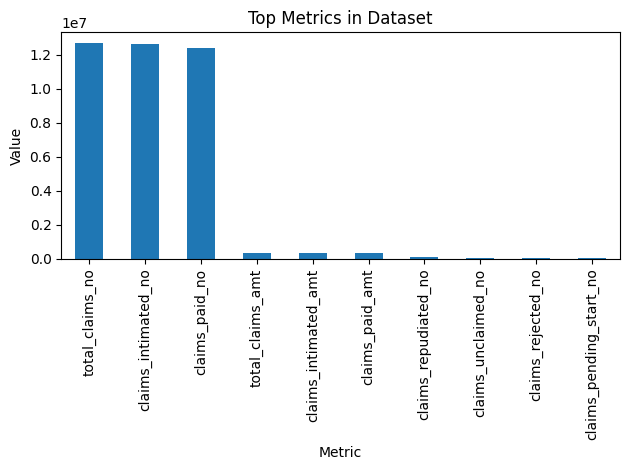


Clean dataset saved as cleaned_claims_data.csv

Analysis Completed Successfully


In [4]:
# ==========================================
# Life Insurance Death Claims Analysis
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------
# 1. Load Dataset (handle encoding issues)
# ------------------------------------------

df = pd.read_csv("li_death_claims.csv", encoding="latin1", low_memory=False)

print("Dataset Loaded Successfully")
print("Shape:", df.shape)

# ------------------------------------------
# 2. View Columns (IMPORTANT)
# ------------------------------------------

print("\nColumns in Dataset:\n")
print(df.columns)

# ------------------------------------------
# 3. Basic Exploration
# ------------------------------------------

print("\nFirst 5 Rows")
print(df.head())

print("\nDataset Info")
print(df.info())

print("\nSummary Statistics")
print(df.describe())

# ------------------------------------------
# 4. Missing Values
# ------------------------------------------

print("\nMissing Values")
print(df.isnull().sum())

df = df.fillna(0)

# ------------------------------------------
# 5. Industry Level Metrics
# ------------------------------------------

# Use actual dataset columns dynamically
numeric_cols = df.select_dtypes(include="number")

print("\nNumeric Columns Used for Analysis:")
print(numeric_cols.columns)

# Total values
totals = numeric_cols.sum()

print("\nTotal Metrics")
print(totals)

# ------------------------------------------
# 6. Group Analysis (by Insurer if exists)
# ------------------------------------------

if "Insurer" in df.columns:

    claims_paid = (
        df.groupby("Insurer")
        .sum(numeric_only=True)
        .sort_values(by=numeric_cols.columns[0], ascending=False)
    )

    print("\nTop Companies:")
    print(claims_paid.head(10))

# ------------------------------------------
# 7. Year Analysis
# ------------------------------------------

if "Year" in df.columns:

    yearly = df.groupby("Year").sum(numeric_only=True)

    print("\nYearly Analysis")
    print(yearly)

# ------------------------------------------
# 8. Visualization
# ------------------------------------------

# Top numeric column visualization
top_metric = numeric_cols.sum().sort_values(ascending=False)

top_metric.head(10).plot(kind="bar")

plt.title("Top Metrics in Dataset")
plt.xlabel("Metric")
plt.ylabel("Value")

plt.tight_layout()
plt.show()

# ------------------------------------------
# 9. Save Clean Dataset
# ------------------------------------------

df.to_csv("cleaned_claims_data.csv", index=False)

print("\nClean dataset saved as cleaned_claims_data.csv")

# ------------------------------------------
# 10. End of Analysis
# ------------------------------------------

print("\nAnalysis Completed Successfully")

In [ ]:
# ==========================================
# Advanced Life Insurance Claims Analysis
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------
# 1. Load Dataset
# ------------------------------------------

df = pd.read_csv("li_death_claims.csv", encoding="latin1", low_memory=False)

print("Dataset Shape:", df.shape)

# ------------------------------------------
# 2. Data Inspection
# ------------------------------------------

print("\nColumns:")
print(df.columns)

print("\nData Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

df.fillna(0, inplace=True)

# ------------------------------------------
# 3. Identify Numeric Columns
# ------------------------------------------

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

print("\nNumeric Columns")
print(numeric_cols)

# ------------------------------------------
# 4. Feature Engineering (KPIs)
# ------------------------------------------

if 'No_of_Claims_Intimated' in df.columns and 'No_of_Claims_Paid' in df.columns:

    df["Settlement_Ratio"] = (
        df["No_of_Claims_Paid"] /
        df["No_of_Claims_Intimated"]
    ) * 100


if 'No_of_Claims_Rejected' in df.columns:

    df["Rejection_Rate"] = (
        df["No_of_Claims_Rejected"] /
        df["No_of_Claims_Intimated"]
    ) * 100


if 'No_of_Claims_Pending_End_of_Year' in df.columns:

    df["Pending_Rate"] = (
        df["No_of_Claims_Pending_End_of_Year"] /
        df["No_of_Claims_Intimated"]
    ) * 100

# ------------------------------------------
# 5. Industry KPI Dashboard
# ------------------------------------------

print("\n========== INDUSTRY KPI ==========")

total_intimated = df["No_of_Claims_Intimated"].sum()
total_paid = df["No_of_Claims_Paid"].sum()
total_rejected = df["No_of_Claims_Rejected"].sum()

industry_ratio = (total_paid / total_intimated) * 100

print("Total Claims Intimated:", total_intimated)
print("Total Claims Paid:", total_paid)
print("Total Claims Rejected:", total_rejected)
print("Industry Settlement Ratio:", round(industry_ratio,2), "%")

# ------------------------------------------
# 6. Company Performance Ranking
# ------------------------------------------

if "Insurer" in df.columns:

    company_performance = df.groupby("Insurer").agg({

        "No_of_Claims_Intimated":"sum",
        "No_of_Claims_Paid":"sum",
        "No_of_Claims_Rejected":"sum"

    })

    company_performance["Settlement_Ratio"] = (
        company_performance["No_of_Claims_Paid"] /
        company_performance["No_of_Claims_Intimated"]
    ) * 100

    company_performance = company_performance.sort_values(
        "Settlement_Ratio",
        ascending=False
    )

    print("\nTop Performing Insurers")
    print(company_performance.head(10))

# ------------------------------------------
# 7. Yearly Trend Analysis
# ------------------------------------------

if "Year" in df.columns:

    yearly_trend = df.groupby("Year").agg({

        "No_of_Claims_Intimated":"sum",
        "No_of_Claims_Paid":"sum"

    })

    print("\nYearly Trend")
    print(yearly_trend)

# ------------------------------------------
# 8. Correlation Analysis
# ------------------------------------------

corr = df[numeric_cols].corr()

print("\nCorrelation Matrix")
print(corr)

plt.figure()

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()

# ------------------------------------------
# 9. Outlier Detection
# ------------------------------------------

for col in numeric_cols:

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\nOutliers in {col}:", len(outliers))

# ------------------------------------------
# 10. Top Claim Paying Companies
# ------------------------------------------

top_companies = df.groupby("Insurer")["No_of_Claims_Paid"].sum()

top_companies = top_companies.sort_values(ascending=False)

print("\nTop Claim Paying Companies")
print(top_companies.head(10))

# ------------------------------------------
# 11. Visualization
# ------------------------------------------

top_companies.head(10).plot(kind="bar")

plt.title("Top 10 Claim Paying Companies")

plt.xlabel("Insurance Company")

plt.ylabel("Claims Paid")

plt.show()

# ------------------------------------------
# 12. Settlement Ratio Distribution
# ------------------------------------------

plt.hist(df["Settlement_Ratio"], bins=20)

plt.title("Settlement Ratio Distribution")

plt.xlabel("Settlement Ratio")

plt.ylabel("Frequency")

plt.show()

# ------------------------------------------
# 13. Save Final Dataset
# ------------------------------------------

df.to_csv("advanced_claims_analysis.csv", index=False)

print("\nSaved file: advanced_claims_analysis.csv")